# Apply LPJ-GUESS July–August climatological FPC anomalies to CLM surface data

This standalone notebook reads historical and future LPJ-GUESS files containing the mean FPC
of July and August from each 30-year climatology, transfers their difference to selected CLM
natural PFTs, and optionally writes a new surface dataset. The legacy input filenames end in
`_max.txt`, but the statistic stored in them is not a maximum.

The workflow is:

1. calculate future minus historical FPC for each LPJ-GUESS PFT on the native grid;
2. convert that anomaly to CLM PFT groups using the exported mapping CSV and plot it;
3. conservatively regrid the grouped anomaly to the CLM grid and plot it;
4. apply it to `PCT_NAT_PFT`, diagnose feasibility constraints, and plot the result;
5. safely write, reopen, and validate the new surface dataset.

FPC is canopy cover, not a closed ground-area partition. The source data are therefore not
normalized. Only the final CLM `PCT_NAT_PFT` distribution is constrained to sum to 100%.

## Method and assumptions

- Both `*_max.txt` files must contain the same statistic: mean July–August FPC from the
  corresponding 30-year climatology.
- `gridlist45N_tundraboreal.txt` is the authoritative LPJ source domain.
- The mapping is read from `lpjguess_to_clm_pft_conversion.csv`; it is not duplicated here.
- CLM natural-PFT indices `1, 2, 3, 5, 7, 8, 11, 12` are modified. PFT 13 (`C3`) and every
  other non-target PFT remain bit-identical.
- LPJ `CLM` is documented in the mapping as residual bare ground. It is not imposed as an
  independent anomaly because CLM bare ground must close the final partition.
- Losses are applied first. A loss is clipped only if CLM contains too little of that PFT.
  Positive gains are proportionally scaled only when they exceed existing bare ground plus
  area released by realised losses.

## 1. Setup

In [1]:
from pathlib import Path
import datetime as dt
import hashlib
import json
import os
import warnings

import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe

warnings.simplefilter("default")
xr.set_options(keep_attrs=True)
plt.rcParams.update({
    "font.family": "STIXGeneral", "mathtext.fontset": "stix",
    "font.size": 11, "axes.titlesize": 12,
})

In [2]:
DATA = Path("/nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata")
SCRIPTS = Path("/cluster/home/adelez/BOREAL-FOREST-EXPANSION/preprocess/edit-surfdatafile/fpc-to-pft-processing")

SURF_IN = DATA / "surfdata_1.9x2.5_hist_78pfts_CMIP6_simyr2000_c190304.nc"
FPC_HIST = DATA / "LPJ-GUESS/fpc1971to2000_max.txt"
FPC_FUT = DATA / "LPJ-GUESS/GFDL-ESM4_SSP585_fpc2071to2100_max.txt"
GRIDLIST = DATA / "LPJ-GUESS/gridlist45N_tundraboreal.txt"

MAPPING_CSV = SCRIPTS / Path("PFT_conversion/lpjguess_to_clm_pft_conversion.csv")

OUTPUT_DIR = Path("LPJGUESS_max_FPC_to_CLM")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
SURF_OUT = DATA / "surfdata_1.9x2.5_SSP5-8.5_2100_78pfts_LPJGUESS.nc"

HIST_PERIOD = "1971–2000"
FUT_PERIOD = "2071–2100"
FPC_STATISTIC = "mean July–August FPC from the 30-year climatology"
SOURCE_RESOLUTION = 0.5
MIN_SOURCE_COVERAGE = 0.50
SAVE_FIGURES = True
WRITE_OUTPUT = False
OVERWRITE = False

if not 0 < MIN_SOURCE_COVERAGE <= 1:
    raise ValueError("MIN_SOURCE_COVERAGE must lie in (0, 1]")
for path in (SURF_IN, FPC_HIST, FPC_FUT, GRIDLIST, MAPPING_CSV):
    if not path.exists():
        raise FileNotFoundError(f"Missing input: {path}")
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load the exported PFT mapping

In [3]:
required_mapping_columns = {
    "lpj_abbrev", "clm_natpft", "clm_abbrev", "treatment", "note",
}
mapping = pd.read_csv(MAPPING_CSV)
missing_columns = required_mapping_columns - set(mapping.columns)
if missing_columns:
    raise ValueError(f"Mapping CSV is missing columns: {sorted(missing_columns)}")

mapped = mapping.loc[mapping["treatment"].eq("mapped")].copy()
mapped["clm_natpft"] = pd.to_numeric(mapped["clm_natpft"], errors="raise").astype(int)
if mapped["lpj_abbrev"].duplicated().any():
    raise ValueError("An LPJ PFT is mapped more than once in the CSV")

CONVERSION_SCHEME = (
    mapped.groupby("clm_natpft", sort=True)["lpj_abbrev"].apply(list).to_dict()
)
EXPECTED_TARGETS = [1, 2, 3, 5, 7, 8, 11, 12]
if sorted(CONVERSION_SCHEME) != EXPECTED_TARGETS:
    raise ValueError(
        f"Expected CLM targets {EXPECTED_TARGETS}, found {sorted(CONVERSION_SCHEME)}"
    )

CLM_NAMES = (
    mapped.drop_duplicates("clm_natpft").set_index("clm_natpft")["clm_abbrev"].to_dict()
)
CLM_NAMES[0] = "BG"
PFTS_TO_CHANGE = sorted(CONVERSION_SCHEME)
BARE = 0

residual_bare_labels = ["mapped_to_bare", "mapped_to_residual_bare"]
natural_rows = mapping.loc[mapping["treatment"].isin(["mapped", *residual_bare_labels])]
LPJ_PFTS = natural_rows["lpj_abbrev"].tolist()
if not mapping["treatment"].isin(residual_bare_labels).any():
    raise ValueError("Mapping CSV must contain the LPJ CLM-to-residual-bare decision")
display(mapping)
print("Conversion scheme:", CONVERSION_SCHEME)

,lpj_index,lpj_abbrev,lpj_name,vegetation_group,clm_natpft,clm_abbrev,treatment,note
0,0,BNE,Boreal needle-leaved evergreen tree,tree,2.0,BoNET,mapped,NaN
1,1,BINE,Boreal shade-intolerant needle-leaved evergree...,tree,2.0,BoNET,mapped,NaN
2,2,BNS,Boreal needle-leaved summergreen tree,tree,3.0,BoNDT,mapped,NaN
3,3,TeNE,Temperate needle-leaved evergreen tree,tree,1.0,TeNET,mapped,NaN
4,4,TeBE,Temperate broad-leaved evergreen tree,tree,5.0,TeBET,mapped,NaN
5,5,IBS,Shade-intolerant broad-leaved summergreen tree,tree,8.0,BoBDT,mapped,NaN
6,6,TeBS,Temperate broad-leaved summergreen tree,tree,7.0,TeBDT,mapped,NaN
7,7,C3G,Cold C3 grass,grass,12.0,arcticC3,mapped,NaN
8,8,HSE,High shrub evergreen,shrub,11.0,BoBDS,mapped,NaN
9,9,HSS,High shrub summergreen,shrub,11.0,BoBDS,mapped,NaN


Conversion scheme: {1: ['TeNE'], 2: ['BNE', 'BINE'], 3: ['BNS'], 5: ['TeBE'], 7: ['TeBS'], 8: ['IBS'], 11: ['HSE', 'HSS', 'LSE', 'LSS', 'EPDS', 'SPDS'], 12: ['C3G', 'GRT']}


## 3. Load and validate July–August climatological FPC files

In [4]:
def find_column(columns, candidates, required=True):
    lookup = {str(column).strip().casefold(): column for column in columns}
    for candidate in candidates:
        if candidate.casefold() in lookup:
            return lookup[candidate.casefold()]
    if required:
        raise KeyError(f"Could not find any of {candidates}; columns are {list(columns)}")
    return None


def normalize_lon(values):
    return ((np.asarray(values, dtype=float) + 180) % 360) - 180


def load_gridlist(path):
    table = pd.read_csv(path, sep=r"\s+", comment="#", dtype=str)
    table.columns = [str(column).strip() for column in table.columns]
    lon_col = find_column(table.columns, ["Lon", "Longitude", "x"], required=False)
    lat_col = find_column(table.columns, ["Lat", "Latitude", "y"], required=False)
    if lon_col is None or lat_col is None:
        table = pd.read_csv(path, sep=r"\s+", comment="#", dtype=str, header=None)
        if table.shape[1] < 2:
            raise ValueError("GRIDLIST must contain longitude and latitude")
        lon_col, lat_col = table.columns[:2]
    grid = table[[lon_col, lat_col]].rename(columns={lon_col: "lon", lat_col: "lat"})
    grid["lon"] = pd.to_numeric(grid["lon"], errors="coerce")
    grid["lat"] = pd.to_numeric(grid["lat"], errors="coerce")
    grid = grid.dropna().copy()
    grid["lon"] = normalize_lon(grid["lon"])
    if grid.duplicated(["lat", "lon"]).any():
        raise ValueError("GRIDLIST contains duplicate normalized coordinates")
    return grid.sort_values(["lat", "lon"]).reset_index(drop=True)


def load_fpc_statistic(path):
    raw = pd.read_csv(path, sep=r"\s+", comment="#", dtype=str)
    raw.columns = [str(column).strip() for column in raw.columns]
    lon_col = find_column(raw.columns, ["Lon", "Longitude"])
    lat_col = find_column(raw.columns, ["Lat", "Latitude"])
    missing_pfts = sorted(set(LPJ_PFTS) - set(raw.columns))
    if missing_pfts:
        raise ValueError(f"{path.name} is missing LPJ PFTs: {missing_pfts}")

    table = raw.rename(columns={lon_col: "lon", lat_col: "lat"})
    table["lon"] = pd.to_numeric(table["lon"], errors="coerce")
    table["lat"] = pd.to_numeric(table["lat"], errors="coerce")
    table = table.dropna(subset=["lon", "lat"])[["lon", "lat", *LPJ_PFTS]].copy()
    table["lon"] = normalize_lon(table["lon"])
    table[LPJ_PFTS] = table[LPJ_PFTS].apply(pd.to_numeric, errors="coerce")
    if table[LPJ_PFTS].isna().any().any():
        raise ValueError(f"Missing or non-numeric FPC in {path.name}")
    if (table[LPJ_PFTS] < -1e-10).any().any():
        raise ValueError(f"Negative FPC in {path.name}")
    if (table[LPJ_PFTS] > 1 + 1e-6).any().any():
        raise ValueError(f"Individual-PFT FPC above 1 in {path.name}")
    duplicates = table.duplicated(["lat", "lon"], keep=False)
    if duplicates.any():
        examples = table.loc[duplicates, ["lon", "lat"]].head().to_dict("records")
        raise ValueError(f"Duplicate coordinates in {path.name}: {examples}")
    return table.sort_values(["lat", "lon"]).reset_index(drop=True)


def spatial_index(table):
    return pd.MultiIndex.from_frame(table[["lat", "lon"]].sort_values(["lat", "lon"]))


authoritative_grid = load_gridlist(GRIDLIST)
historical = load_fpc_statistic(FPC_HIST)
future = load_fpc_statistic(FPC_FUT)
expected_index = spatial_index(authoritative_grid)

for label, table in [(HIST_PERIOD, historical), (FUT_PERIOD, future)]:
    actual_index = spatial_index(table)
    missing = expected_index.difference(actual_index)
    extra = actual_index.difference(expected_index)
    if len(missing) or len(extra):
        raise ValueError(
            f"{label} does not match GRIDLIST: missing={len(missing)}, extra={len(extra)}; "
            f"missing examples={list(missing[:5])}; extra examples={list(extra[:5])}"
        )
if not spatial_index(historical).equals(spatial_index(future)):
    raise ValueError("Historical and future July–August FPC grids differ")

input_summary = pd.DataFrame([
    {"period": HIST_PERIOD, "file": FPC_HIST.name, "cells": len(historical)},
    {"period": FUT_PERIOD, "file": FPC_FUT.name, "cells": len(future)},
    {"period": "authoritative domain", "file": GRIDLIST.name, "cells": len(authoritative_grid)},
])
display(input_summary)

,period,file,cells
0,1971–2000,fpc1971to2000_max.txt,16750
1,2071–2100,GFDL-ESM4_SSP585_fpc2071to2100_max.txt,16750
2,authoritative domain,gridlist45N_tundraboreal.txt,16750


The validation is intentionally strict: both FPC files must contain exactly the cells in the
authoritative grid list. A mismatch is not filled silently because it would change the spatial
support of the anomaly.

## 4. Calculate the native-grid LPJ anomaly and convert it to CLM PFTs

In [ ]:
raw_delta = historical[["lat", "lon"]].copy()
raw_delta[LPJ_PFTS] = future[LPJ_PFTS] - historical[LPJ_PFTS]


def aggregate_to_clm(table):
    result = table[["lat", "lon"]].copy()
    for clm_pft, lpj_pfts in CONVERSION_SCHEME.items():
        result[f"pft_{clm_pft}"] = table[lpj_pfts].sum(axis=1)
    return result


historical_clm = aggregate_to_clm(historical)
future_clm = aggregate_to_clm(future)
delta_clm_table = aggregate_to_clm(raw_delta)
pft_columns = [f"pft_{pft}" for pft in PFTS_TO_CHANGE]

# Aggregation is linear, so these two routes must be numerically identical.
np.testing.assert_allclose(
    delta_clm_table[pft_columns],
    future_clm[pft_columns] - historical_clm[pft_columns],
    rtol=0, atol=1e-12,
)

source_qc = pd.DataFrame({
    "metric": [
        "source cells",
        "historical sum of mapped FPC > 1",
        "future sum of mapped FPC > 1",
        "largest historical mapped FPC sum",
        "largest future mapped FPC sum",
    ],
    "value": [
        len(historical),
        int((historical_clm[pft_columns].sum(axis=1) > 1).sum()),
        int((future_clm[pft_columns].sum(axis=1) > 1).sum()),
        float(historical_clm[pft_columns].sum(axis=1).max()),
        float(future_clm[pft_columns].sum(axis=1).max()),
    ],
})
display(source_qc)

A sum above 1 is retained. All PFTs refer to the same July–August averaging window, but FPC can
still overlap vertically. The sum is therefore a canopy-cover diagnostic, not a ground-area
partition to normalize.

## 5. Build the regular source grid and plot converted FPC

In [6]:
def regular_centres(resolution):
    lon = np.arange(-180 + resolution / 2, 180, resolution)
    lat = np.arange(-90 + resolution / 2, 90, resolution)
    return lat, lon


def assert_regular(values, centres, resolution, name):
    index = (np.asarray(values) - centres[0]) / resolution
    if np.abs(index - np.rint(index)).max(initial=0) > 1e-6:
        raise ValueError(f"{name} is not on the configured {resolution}° grid")


def table_to_array(table):
    lat, lon = regular_centres(SOURCE_RESOLUTION)
    assert_regular(table["lat"].unique(), lat, SOURCE_RESOLUTION, "Latitude")
    assert_regular(table["lon"].unique(), lon, SOURCE_RESOLUTION, "Longitude")
    dataset = table.set_index(["lat", "lon"]).to_xarray().reindex(lat=lat, lon=lon)
    arrays = [dataset[f"pft_{pft}"].expand_dims(natpft=[pft]) for pft in PFTS_TO_CHANGE]
    return xr.concat(arrays, dim="natpft").transpose("natpft", "lat", "lon")


historical_src = table_to_array(historical_clm)
future_src = table_to_array(future_clm)
delta_src = table_to_array(delta_clm_table)
source_mask = (
    authoritative_grid.assign(valid=1).set_index(["lat", "lon"]).to_xarray()["valid"]
    .reindex(lat=delta_src.lat, lon=delta_src.lon).fillna(0).astype(bool)
)

missing_on_domain = (
    historical_src.isnull().any("natpft") | future_src.isnull().any("natpft")
    | delta_src.isnull().any("natpft")
) & source_mask
if bool(missing_on_domain.any()):
    raise ValueError(f"Missing converted FPC inside GRIDLIST: {int(missing_on_domain.sum())} cells")

historical_src = historical_src.where(source_mask)
future_src = future_src.where(source_mask)
delta_src = delta_src.where(source_mask)

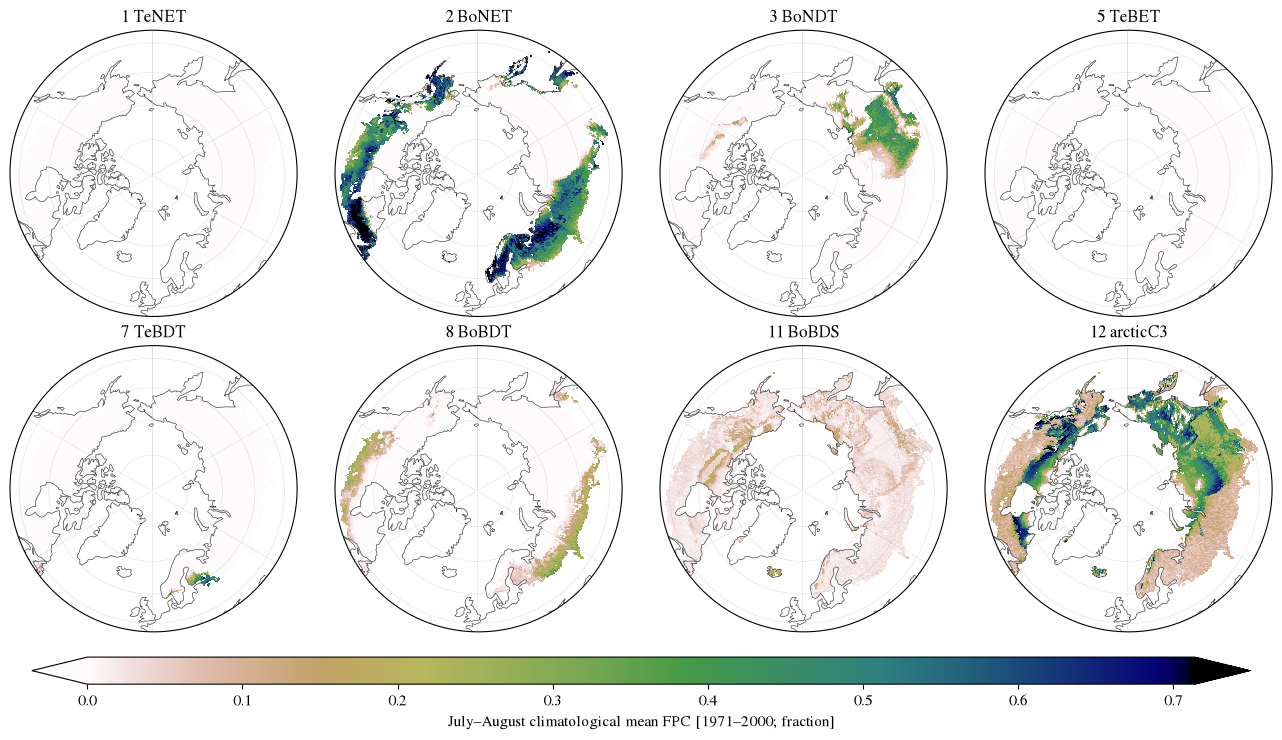

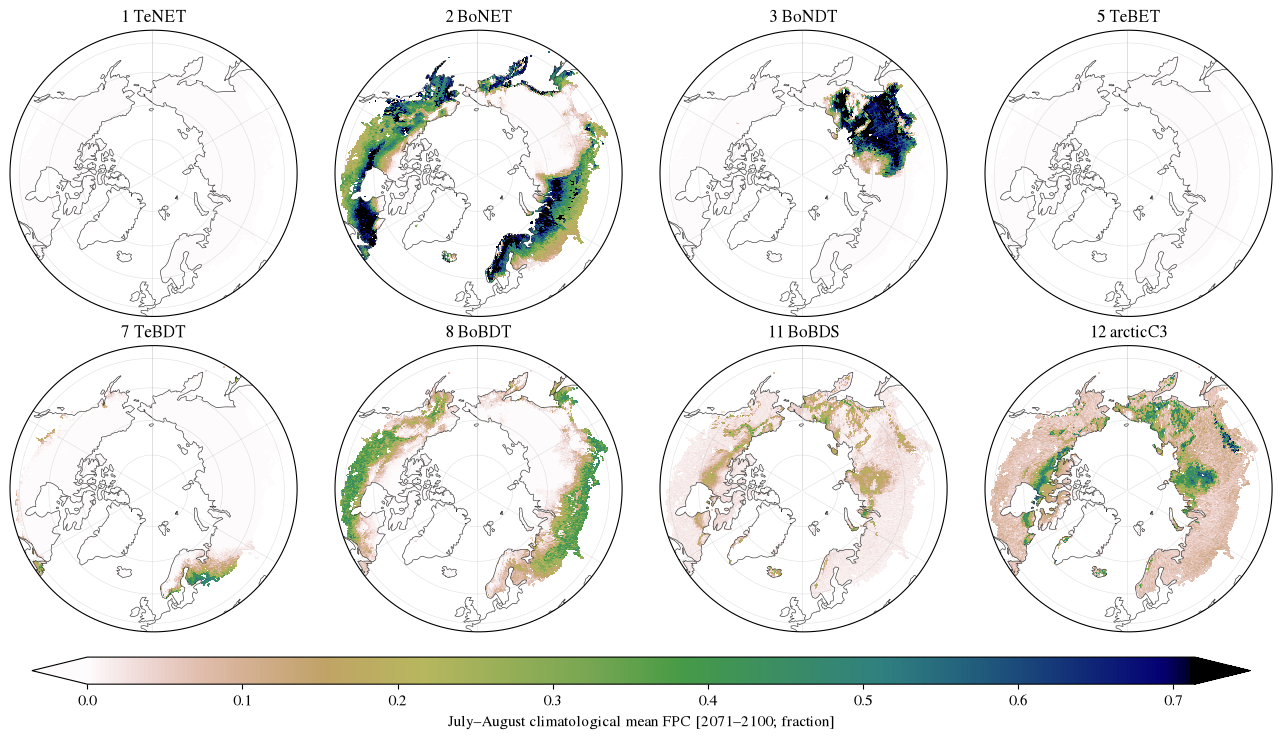

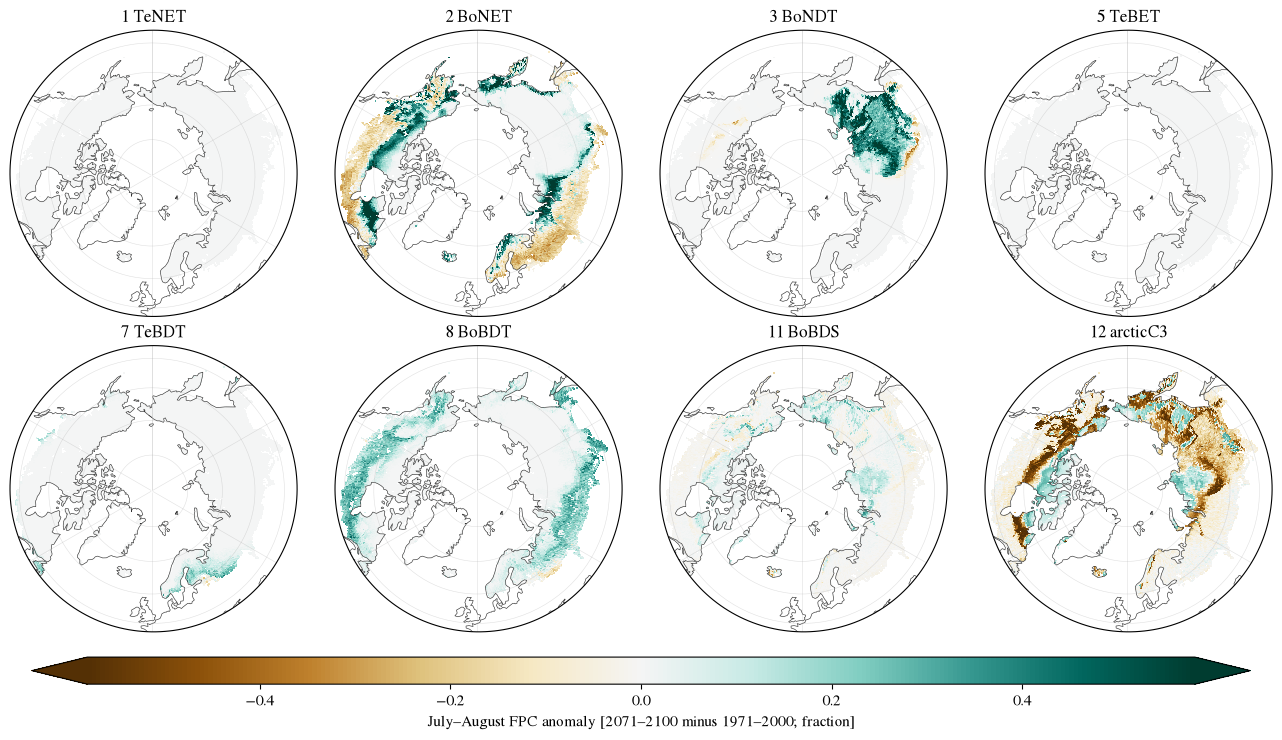

In [7]:
def circular_boundary(ax):
    angle = np.linspace(0, 2 * np.pi, 200)
    vertices = np.column_stack([np.sin(angle), np.cos(angle)]) * 0.5 + 0.5
    ax.set_boundary(mpath.Path(vertices), transform=ax.transAxes)


def save_figure(fig, name):
    if not SAVE_FIGURES:
        return
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=220, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")


def map_panel(fields, titles, label, cmap, norm, ncols=4):
    nrows = int(np.ceil(len(fields) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.25 * ncols, 3.35 * nrows + 0.6),
        subplot_kw={"projection": ccrs.Orthographic(0, 90)}, layout="constrained",
    )
    axes = np.atleast_1d(axes).ravel()
    image = None
    for ax, field, title in zip(axes, fields, titles):
        ax.set_extent([-180, 180, 45, 90], ccrs.PlateCarree())
        circular_boundary(ax)
        image = field.plot.pcolormesh(
            ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(),
            cmap=cmap, norm=norm, add_colorbar=False,
        )
        ax.coastlines(linewidth=0.45, color="0.2")
        ax.gridlines(linewidth=0.4, color="0.65", alpha=0.35)
        ax.set_title(title)
    for ax in axes[len(fields):]:
        ax.set_visible(False)
    colorbar = fig.colorbar(
        image, ax=list(axes[:len(fields)]), orientation="horizontal",
        fraction=0.045, pad=0.04, aspect=45, extend="both",
    )
    colorbar.set_label(label)
    return fig


pft_titles = [f"{pft} {CLM_NAMES[pft]}" for pft in PFTS_TO_CHANGE]
cover_values = np.concatenate([
    historical_src.values[np.isfinite(historical_src.values)],
    future_src.values[np.isfinite(future_src.values)],
])
cover_vmax = max(float(np.percentile(cover_values, 99)), 0.05)
cover_norm = mcolors.Normalize(0, cover_vmax)

for label, field, filename in [
    (HIST_PERIOD, historical_src, "historical_july_august_fpc_clm_groups_native_grid"),
    (FUT_PERIOD, future_src, "future_july_august_fpc_clm_groups_native_grid"),
]:
    fig = map_panel(
        [field.sel(natpft=pft) for pft in PFTS_TO_CHANGE], pft_titles,
        f"July–August climatological mean FPC [{label}; fraction]", "gist_earth_r", cover_norm,
    )
    save_figure(fig, filename)
    plt.show()

source_abs = np.abs(delta_src.values[np.isfinite(delta_src.values)])
source_vmax = max(float(np.percentile(source_abs, 99)), 1e-4)
fig = map_panel(
    [delta_src.sel(natpft=pft) for pft in PFTS_TO_CHANGE], pft_titles,
    f"July–August FPC anomaly [{FUT_PERIOD} minus {HIST_PERIOD}; fraction]",
    "BrBG", mcolors.TwoSlopeNorm(vmin=-source_vmax, vcenter=0, vmax=source_vmax),
)
save_figure(fig, "july_august_fpc_anomaly_clm_groups_native_grid")
plt.show()

## 6. Load CLM and regrid the converted anomaly

In [8]:
def convert_lsmcoord(dataset):
    if {"lat", "lon"}.issubset(dataset.dims):
        return dataset
    converted = dataset.assign_coords(
        lsmlat=dataset["LATIXY"].isel(lsmlon=0).values,
        lsmlon=dataset["LONGXY"].isel(lsmlat=0).values,
    )
    return converted.rename({"lsmlat": "lat", "lsmlon": "lon"})


def convert360_180(data):
    if float(data.lon.min()) >= 0:
        data = data.assign_coords(lon=((data.lon + 180) % 360) - 180).sortby("lon")
    return data


def convert180_360(data):
    if float(data.lon.min()) < 0:
        data = data.assign_coords(lon=data.lon % 360).sortby("lon")
    return data


def bounds_1d(values):
    values = np.asarray(values, dtype=float)
    spacing = np.diff(values)
    if not np.allclose(spacing, spacing[0], rtol=0, atol=1e-8):
        raise ValueError("Conservative regridding requires regular coordinates")
    midpoints = 0.5 * (values[:-1] + values[1:])
    return np.r_[values[0] - spacing[0] / 2, midpoints, values[-1] + spacing[-1] / 2]


def make_grid(lat, lon, mask=None):
    grid = xr.Dataset({
        "lat": ("lat", np.asarray(lat)), "lon": ("lon", np.asarray(lon)),
        "lat_b": ("lat_b", np.clip(bounds_1d(lat), -90, 90)),
        "lon_b": ("lon_b", bounds_1d(lon)),
    })
    if mask is not None:
        grid["mask"] = mask.astype(np.int32)
    return grid


surf = xr.open_dataset(SURF_IN)
surf_geo = convert_lsmcoord(surf)
pct_clm = convert360_180(surf_geo["PCT_NAT_PFT"])
landfrac = convert360_180(surf_geo["LANDFRAC_PFT"])
natveg = convert360_180(surf_geo["PCT_NATVEG"])
valid_clm = (
    (landfrac > 0) & (natveg > 0)
    & (np.abs(pct_clm.sum("natpft", skipna=False) - 100) < 1e-3)
).fillna(False)

<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


In [9]:
src_grid_masked = make_grid(delta_src.lat.values, delta_src.lon.values, source_mask)
src_grid_full = make_grid(delta_src.lat.values, delta_src.lon.values)
dst_grid = make_grid(pct_clm.lat.values, pct_clm.lon.values)

anomaly_regridder = xe.Regridder(
    src_grid_masked, dst_grid, "conservative_normed",
    unmapped_to_nan=True, ignore_degenerate=False,
)
delta_regridded = anomaly_regridder(delta_src, keep_attrs=True, skipna=True, na_thres=1.0)

coverage_regridder = xe.Regridder(
    src_grid_full, dst_grid, "conservative",
    unmapped_to_nan=True, ignore_degenerate=False,
)
source_coverage = coverage_regridder(source_mask.astype(float)).clip(0, 1)
finite_anomaly = np.isfinite(delta_regridded).all("natpft")
adequate_coverage = source_coverage >= MIN_SOURCE_COVERAGE
modify_domain = valid_clm & finite_anomaly & adequate_coverage

if not bool(modify_domain.any()):
    raise ValueError("No CLM cell passes validity and LPJ coverage checks")
missing_inside_domain = delta_regridded.isnull().any("natpft") & modify_domain
if bool(missing_inside_domain.any()):
    raise ValueError(f"Missing anomaly inside modification domain: {int(missing_inside_domain.sum())}")

coverage_summary = pd.DataFrame({
    "metric": [
        "valid CLM cells", "cells with finite anomaly",
        f"cells with source coverage >= {MIN_SOURCE_COVERAGE:.0%}",
        "cells selected for modification", "minimum retained source coverage",
    ],
    "value": [
        int(valid_clm.sum()), int(finite_anomaly.sum()), int(adequate_coverage.sum()),
        int(modify_domain.sum()), float(source_coverage.where(modify_domain).min()),
    ],
})
display(coverage_summary)

,metric,value
0,valid CLM cells,4914.000000
1,cells with finite anomaly,1309.000000
2,cells with source coverage >= 50%,876.000000
3,cells selected for modification,876.000000
4,minimum retained source coverage,0.501878


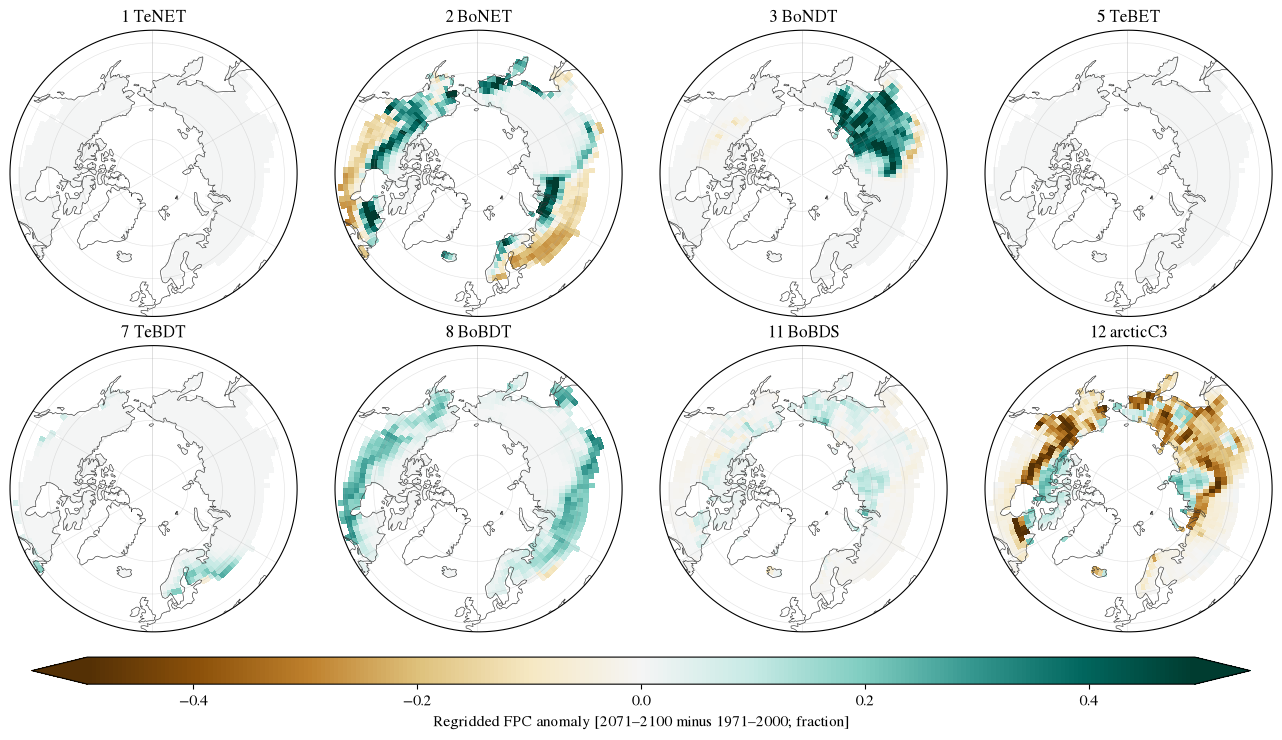

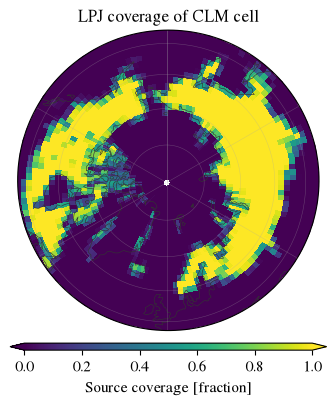

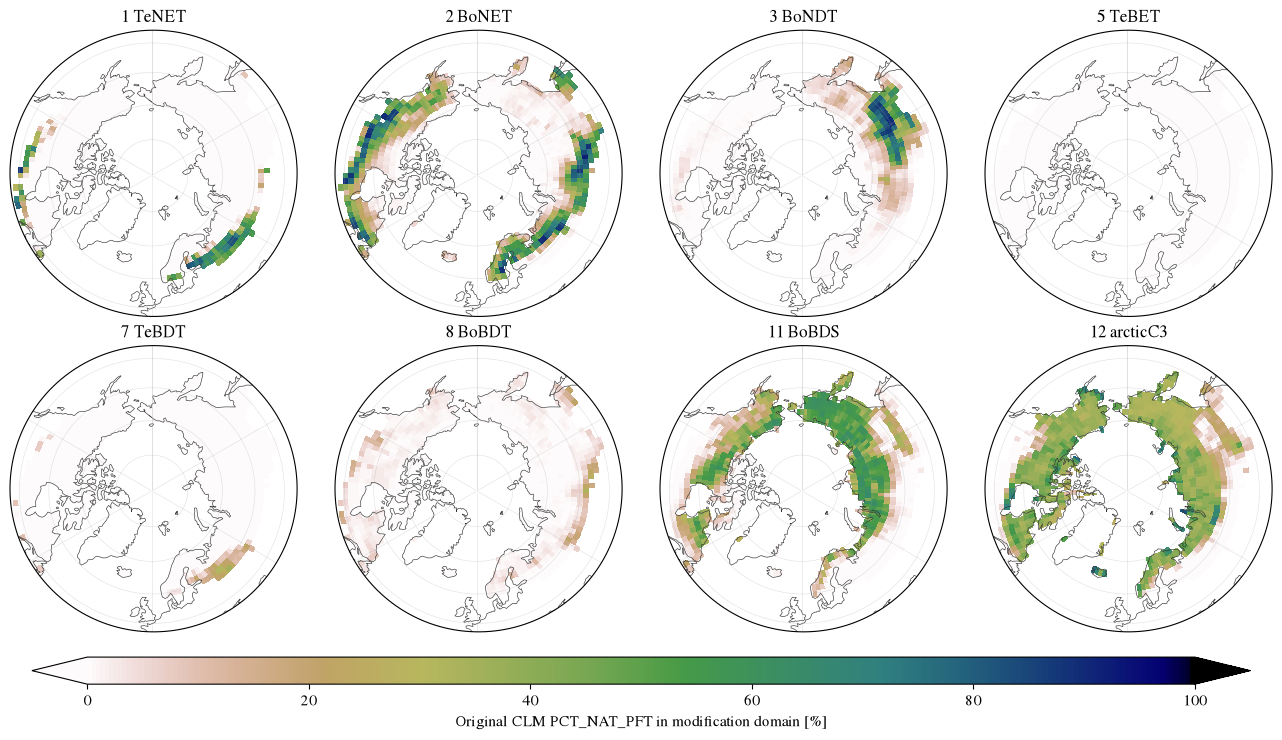

In [10]:
target_abs = np.abs(delta_regridded.where(modify_domain).values)
target_abs = target_abs[np.isfinite(target_abs)]
target_vmax = max(float(np.percentile(target_abs, 99)), 1e-4)
fig = map_panel(
    [delta_regridded.sel(natpft=pft).where(modify_domain) for pft in PFTS_TO_CHANGE],
    pft_titles, f"Regridded FPC anomaly [{FUT_PERIOD} minus {HIST_PERIOD}; fraction]",
    "BrBG", mcolors.TwoSlopeNorm(vmin=-target_vmax, vcenter=0, vmax=target_vmax),
)
save_figure(fig, "july_august_fpc_anomaly_regridded_to_clm")
plt.show()

fig = map_panel(
    [source_coverage], ["LPJ coverage of CLM cell"], "Source coverage [fraction]",
    "viridis", mcolors.Normalize(0, 1), ncols=1,
)
save_figure(fig, "lpj_source_coverage_on_clm_grid")
plt.show()

fig = map_panel(
    [pct_clm.sel(natpft=pft).where(modify_domain) for pft in PFTS_TO_CHANGE],
    pft_titles, "Original CLM PCT_NAT_PFT in modification domain [%]",
    "gist_earth_r", mcolors.Normalize(0, 100),
)
save_figure(fig, "original_clm_pct_nat_pft_in_modification_domain")
plt.show()

## 7. Apply losses first and constrain gains

In [11]:
delta_requested = 100 * delta_regridded.sel(natpft=PFTS_TO_CHANGE)
base_changed = pct_clm.sel(natpft=PFTS_TO_CHANGE)
untouched = [
    int(pft) for pft in pct_clm.natpft.values
    if int(pft) not in PFTS_TO_CHANGE and int(pft) != BARE
]
untouched_sum = pct_clm.sel(natpft=untouched).sum("natpft")
block_total = 100 - untouched_sum
if float(block_total.where(valid_clm).min()) < -1e-8:
    raise ValueError("Untouched CLM PFTs exceed 100% in at least one valid cell")

requested_loss = xr.where(delta_requested < 0, delta_requested, 0)
requested_gain = xr.where(delta_requested > 0, delta_requested, 0)
after_loss = (base_changed + requested_loss).clip(min=0)
realised_loss = after_loss - base_changed

raw_gain_capacity = block_total - after_loss.sum("natpft")
if float(raw_gain_capacity.where(valid_clm).min()) < -1e-8:
    raise ValueError("Negative gain capacity before clipping; inspect the CLM baseline")
gain_capacity = raw_gain_capacity.clip(min=0)
requested_gain_sum = requested_gain.sum("natpft")
gain_scale = xr.where(
    requested_gain_sum > 0,
    np.minimum(1.0, gain_capacity / requested_gain_sum),
    1.0,
)

new_changed = after_loss + requested_gain * gain_scale
new_bare = block_total - new_changed.sum("natpft")
pct_new = pct_clm.copy(deep=True)
pct_new.loc[dict(natpft=PFTS_TO_CHANGE)] = new_changed
pct_new.loc[dict(natpft=BARE)] = new_bare
pct_new = xr.where(modify_domain, pct_new, pct_clm)

realised_delta = (pct_new - pct_clm).sel(natpft=PFTS_TO_CHANGE)
adjustment = realised_delta - delta_requested
loss_clipped = (requested_loss < realised_loss - 1e-10).any("natpft") & modify_domain
gain_scaled = (gain_scale < 1 - 1e-10) & modify_domain
zero_capacity = (requested_gain_sum > 1e-10) & (gain_capacity <= 1e-10) & modify_domain

constraint_summary = pd.DataFrame({
    "metric": [
        "cells with a clipped loss", "cells with scaled gains",
        "gain cells with zero capacity", "minimum gain scale",
    ],
    "value": [
        int(loss_clipped.sum()), int(gain_scaled.sum()), int(zero_capacity.sum()),
        float(gain_scale.where(modify_domain).min()),
    ],
})
display(constraint_summary)

,metric,value
0,cells with a clipped loss,340.0
1,cells with scaled gains,712.0
2,gain cells with zero capacity,14.0
3,minimum gain scale,0.0


## 8. Validate and summarize requested versus realised changes

In [12]:
def spherical_cell_area(lat, lon, radius=6_371_000.0):
    lat_b = np.deg2rad(np.clip(bounds_1d(lat), -90, 90))
    lon_b = np.deg2rad(bounds_1d(lon))
    values = radius**2 * np.diff(np.sin(lat_b))[:, None] * np.diff(lon_b)[None, :]
    return xr.DataArray(values, coords={"lat": lat, "lon": lon}, dims=("lat", "lon"))


def weighted_mean(field, weights, mask):
    usable = mask & np.isfinite(field) & np.isfinite(weights) & (weights > 0)
    denominator = weights.where(usable).sum()
    return float((field.where(usable) * weights.where(usable)).sum() / denominator)


partition_error = np.abs(pct_new.sum("natpft", skipna=False) - 100).where(valid_clm)
assert float(partition_error.max(skipna=True)) < 1e-8
assert float(pct_new.where(valid_clm).min(skipna=True)) >= -1e-8
assert float(pct_new.where(valid_clm).max(skipna=True)) <= 100 + 1e-8
xr.testing.assert_identical(pct_new.sel(natpft=untouched), pct_clm.sel(natpft=untouched))
xr.testing.assert_identical(pct_new.where(~modify_domain), pct_clm.where(~modify_domain))

weights = spherical_cell_area(pct_clm.lat.values, pct_clm.lon.values) * landfrac * natveg / 100
rows = []
for pft in PFTS_TO_CHANGE:
    requested = delta_requested.sel(natpft=pft)
    realised = realised_delta.sel(natpft=pft)
    rows.append({
        "clm_natpft": pft, "clm_abbrev": CLM_NAMES[pft],
        "requested_mean_pp": weighted_mean(requested, weights, modify_domain),
        "realised_mean_pp": weighted_mean(realised, weights, modify_domain),
        "mean_adjustment_pp": weighted_mean(realised - requested, weights, modify_domain),
        "max_abs_adjustment_pp": float(np.abs(realised - requested).where(modify_domain).max()),
    })

bare_delta = (pct_new - pct_clm).sel(natpft=BARE)
rows.append({
    "clm_natpft": BARE, "clm_abbrev": "BG", "requested_mean_pp": np.nan,
    "realised_mean_pp": weighted_mean(bare_delta, weights, modify_domain),
    "mean_adjustment_pp": np.nan, "max_abs_adjustment_pp": np.nan,
})
change_summary = pd.DataFrame(rows).sort_values("clm_natpft")
display(change_summary.round(4))
print(f"Worst |PFT sum - 100|: {float(partition_error.max()):.3e}")

source_qc.to_csv(TABLE_DIR / "source_qc.csv", index=False)
coverage_summary.to_csv(TABLE_DIR / "target_coverage_qc.csv", index=False)
constraint_summary.to_csv(TABLE_DIR / "allocation_constraints.csv", index=False)
change_summary.to_csv(TABLE_DIR / "requested_vs_realised_change.csv", index=False)

AssertionError: DataArray names are different. L: None, R: PCT_NAT_PFT

## 9. Plot requested, realised, adjustment, and final distributions

In [ ]:
change_arrays = [
    delta_requested.where(modify_domain), realised_delta.where(modify_domain),
    adjustment.where(modify_domain),
]
finite = np.concatenate([
    np.abs(array.values[np.isfinite(array.values)]) for array in change_arrays
])
change_vmax = max(float(np.percentile(finite, 99)), 0.01)
change_norm = mcolors.TwoSlopeNorm(vmin=-change_vmax, vcenter=0, vmax=change_vmax)

for label, field, filename in [
    ("Requested", delta_requested, "requested_pct_nat_pft_change"),
    ("Realised", realised_delta, "realised_pct_nat_pft_change"),
    ("Realised minus requested", adjustment, "constraint_adjustment"),
]:
    fig = map_panel(
        [field.sel(natpft=pft).where(modify_domain) for pft in PFTS_TO_CHANGE],
        pft_titles, f"{label} PCT_NAT_PFT change [percentage points]", "BrBG", change_norm,
    )
    save_figure(fig, filename)
    plt.show()

final_pfts = [BARE, *PFTS_TO_CHANGE]
final_titles = [f"{pft} {CLM_NAMES.get(pft, str(pft))}" for pft in final_pfts]
fig = map_panel(
    [pct_new.sel(natpft=pft).where(modify_domain) for pft in final_pfts],
    final_titles, "Final CLM PCT_NAT_PFT [%]", "gist_earth_r", mcolors.Normalize(0, 100),
)
save_figure(fig, "final_clm_pct_nat_pft")
plt.show()

## 10. Safely write and reopen the surface dataset

In [ ]:
def sha256(path, chunk_size=1024**2):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def safe_encoding(dataset):
    allowed = {
        "zlib", "complevel", "shuffle", "fletcher32", "contiguous", "chunksizes",
        "dtype", "_FillValue", "endian", "least_significant_digit", "significant_digits",
    }
    return {
        name: {key: value for key, value in variable.encoding.items() if key in allowed}
        for name, variable in dataset.variables.items()
    }


if WRITE_OUTPUT:
    if SURF_OUT.exists() and not OVERWRITE:
        raise FileExistsError(f"Output exists; set OVERWRITE=True to replace it: {SURF_OUT}")

    pct_native = convert180_360(pct_new)
    original = surf_geo["PCT_NAT_PFT"]
    if not np.allclose(pct_native.lat, original.lat):
        raise ValueError("Latitude order does not match the input surfdata")
    if not np.allclose(pct_native.lon, original.lon):
        raise ValueError("Longitude order does not match the input surfdata")
    if not np.array_equal(pct_native.natpft, original.natpft):
        raise ValueError("Natural-PFT coordinate does not match the input surfdata")

    surf_out = surf.copy(deep=True)
    surf_out["PCT_NAT_PFT"] = xr.DataArray(
        pct_native.transpose("natpft", "lat", "lon").values,
        dims=surf["PCT_NAT_PFT"].dims, coords=surf["PCT_NAT_PFT"].coords,
        attrs=surf["PCT_NAT_PFT"].attrs,
    )
    xr.testing.assert_identical(surf_out.drop_vars("PCT_NAT_PFT"), surf.drop_vars("PCT_NAT_PFT"))

    provenance = {
        "method": (
            "July–August mean FPC anomaly from 30-year climatologies; losses first; "
            "positive gains scaled only if infeasible"
        ),
        "fpc_statistic": FPC_STATISTIC,
        "historical_period": HIST_PERIOD, "future_period": FUT_PERIOD,
        "historical_file": FPC_HIST.name, "future_file": FPC_FUT.name,
        "mapping_file": MAPPING_CSV.name, "gridlist_file": GRIDLIST.name,
        "historical_sha256": sha256(FPC_HIST), "future_sha256": sha256(FPC_FUT),
        "mapping_sha256": sha256(MAPPING_CSV), "gridlist_sha256": sha256(GRIDLIST),
        "minimum_source_coverage": MIN_SOURCE_COVERAGE,
        "pft_mapping": CONVERSION_SCHEME,
        "cells_modified": int(modify_domain.sum()),
        "cells_loss_clipped": int(loss_clipped.sum()),
        "cells_gain_scaled": int(gain_scaled.sum()),
        "cells_zero_gain_capacity": int(zero_capacity.sum()),
    }
    surf_out.attrs.update({
        "title": "CLM surfdata with LPJ-GUESS July–August climatological FPC anomalies",
        "history": (
            f"{dt.date.today():%Y-%m-%d}: PCT_NAT_PFT modified using July–August FPC anomaly "
            f"({FUT_PERIOD} minus {HIST_PERIOD}).\n" + surf.attrs.get("history", "")
        ),
        "comment": (
            "Only PCT_NAT_PFT changed. PCT_NATVEG and other land-unit fractions are fixed. "
            "LPJ FPC was not normalized as a ground-area partition."
        ),
        "lpjguess_to_clm_provenance": json.dumps(provenance, sort_keys=True),
    })

    SURF_OUT.parent.mkdir(parents=True, exist_ok=True)
    temporary = SURF_OUT.with_suffix(SURF_OUT.suffix + ".tmp")
    surf_out.to_netcdf(temporary, format="NETCDF4", encoding=safe_encoding(surf_out))
    with xr.open_dataset(temporary) as check:
        written = check["PCT_NAT_PFT"]
        assert not bool(written.isnull().any())
        assert float(np.abs(written.sum("natpft", skipna=False) - 100).max()) < 1e-6
        assert float(written.min()) >= -1e-8
        assert float(written.max()) <= 100 + 1e-8
    os.replace(temporary, SURF_OUT)
    print(f"Saved and reopened successfully: {SURF_OUT}")
else:
    print("WRITE_OUTPUT=False: diagnostics completed; no surface dataset was written.")

## Run checklist

Before setting `WRITE_OUTPUT = True`, inspect:

- the native and regridded anomaly maps;
- the coverage map and number of retained CLM cells;
- cells with clipped losses, scaled gains, or zero gain capacity;
- requested, realised, and adjustment maps;
- the residual bare-ground change and the final distribution;
- the output filename and period labels.